# Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

# Loading the data

### It is recommended to upload the zipped EMNIST dataset to your Google Drive.

### Then, mount Google Drive and import the dataset (by executing the following code).

In [2]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Unzipping .zip dataset file from drive to /content folder of your colab notebook

import shutil
import zipfile

zip_file_path = '/content/drive/MyDrive/A_Z Handwritten Data.zip' # Change as per your dataset file path in drive
extracted_dir = '/content'

import os
os.makedirs(extracted_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)


In [4]:
data = pd.read_csv('A_Z Handwritten Data.csv')

# Display this dataset
# It's first column contains all the labels (o to 25 for A to Z) and the remaining 784 columns contain pixel values.
# Seperate them accordingly as X (for pixel values) and Y (for labels)
# Convert these to numpy arrays
# Normalize the X array (X/255), normalizing by 255 scales pixel values to a range between 0 and 1, promoting numerical stability, consistent scale across features, and optimizing the sensitivity of activation functions during neural network training.
# As you can see, this dataset is sorted from A to Z, it needs to be shuffled before it can be used for training
# Shuffle the dataset
# Create training and validation sets

In [5]:
from sklearn.model_selection import train_test_split

# Extract labels (Y) and pixel values (X)
Y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values

# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

# Normalize the pixel values
X = X / 255.0

# Shuffle the dataset
shuffle_index = np.random.permutation(len(X))
X_shuffled = X[shuffle_index]
Y_shuffled = Y[shuffle_index]

# Split the dataset into training and validation sets
# Adjust the test_size and random_state parameters as needed
X_train, X_val, Y_train, Y_val = train_test_split(X_shuffled, Y_shuffled, test_size=0.2, random_state=42)

# Display the shapes of the resulting arrays
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_val shape:", X_val.shape)
print("Y_val shape:", Y_val.shape)


X_train shape: (297960, 784)
Y_train shape: (297960,)
X_val shape: (74490, 784)
Y_val shape: (74490,)


In [ ]:
# Display a single training set sample along with its label using matplot heatmap

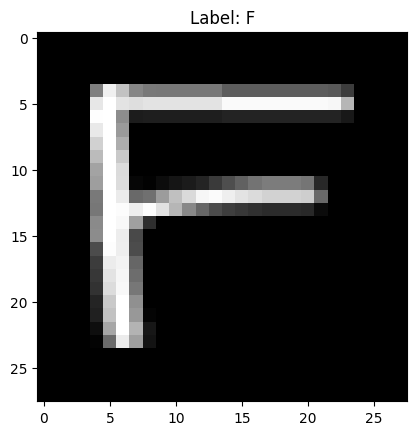

In [6]:
import random
import matplotlib.pyplot as plt

# Choose a random index for the sample you want to visualize
random_index = random.randint(0, len(X_train) - 1)

# Extract the random sample and label from the training set
random_sample = X_train[random_index].reshape(28, 28)  # Assuming the images are 28x28 pixels
random_label = Y_train[random_index]

# Display the random sample using a heatmap
plt.imshow(random_sample, cmap='gray')
plt.title(f"Label: {chr(ord('A') + random_label)}")  # Convert label to corresponding alphabet character
plt.show()


# Model

In [ ]:
# You can copy-paste your MNIST model and make necessary changes to train the model on EMNIST
# Changes would include : Shapes of weight matrices, no. of output nodes and return vector of one_hot function
# Note that you might need to increase number of nodes in the hidden layers too to accomodate for the additional output information compared to MNIST
# Experiment with these numbers and find the optimal number of nodes for each layer

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

# Assuming you have already loaded and preprocessed the EMNIST dataset
# X_train, Y_train, X_val, Y_val = preprocess_emnist_data()

# Parameters
i = 784  # Input size (no. of pixels = 28*28 = 784)
h1 = 128  # No. of nodes for 1st hidden layer (increased for more complex dataset)
h2 = 64  # No. of nodes for 2nd hidden layer
o = 26    # Output size (26 classes for A to Z)
lr = 0.02  # Initial learning rate
epochs = 10  # No. of epochs
batch_size = 32  # Mini-batch size

# Initialize the weights and biases with consistent random initialization
np.random.seed(42)
W1 = np.random.randn(i, h1)
b1 = np.zeros((1, h1))
W2 = np.random.randn(h1, h2)
b2 = np.zeros((1, h2))
W3 = np.random.randn(h2, o)
b3 = np.zeros((1, o))

# Defining Activation Functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_prime(z):
    return sigmoid(z) * (1 - sigmoid(z))

def one_hot(y, num_classes):
    one_hot_encoded = np.zeros((len(y), num_classes))
    one_hot_encoded[np.arange(len(y)), y] = 1
    return one_hot_encoded

# Training Loop
for ep in range(epochs):
    total_cost = 0
    correct_predictions = 0

    # Mini-Batch Gradient Descent
    for start in range(0, len(X_train), batch_size):
        end = start + batch_size
        X_batch = X_train[start:end]
        Y_batch = Y_train[start:end]

        # Forward Propagation
        z1 = np.dot(X_batch, W1) + b1
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)
        z3 = np.dot(a2, W3) + b3
        y_predicted = sigmoid(z3)

        # Convert label to one hot encoded vector
        y_one_hot = one_hot(Y_batch, num_classes=o)

        # Calculate the cost (cross-entropy loss)
        cost = -np.sum(y_one_hot * np.log(y_predicted + 1e-10))

        # Back Propagation
        dz3 = y_predicted - y_one_hot
        dW3 = np.dot(a2.T, dz3)
        db3 = np.sum(dz3, axis=0, keepdims=True)
        dz2 = np.dot(dz3, W3.T) * sigmoid_prime(z2)
        dW2 = np.dot(a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)
        dz1 = np.dot(dz2, W2.T) * sigmoid_prime(z1)
        dW1 = np.dot(X_batch.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update weights and biases
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        W3 -= lr * dW3
        b3 -= lr * db3

        total_cost += cost

        # Check accuracy
        predictions = np.argmax(y_predicted, axis=1)
        correct_predictions += np.sum(predictions == Y_batch)

    # Forward propagation for the validation set
    z1_val = np.dot(X_val, W1) + b1
    a1_val = sigmoid(z1_val)
    z2_val = np.dot(a1_val, W2) + b2
    a2_val = sigmoid(z2_val)
    z3_val = np.dot(a2_val, W3) + b3
    y_val_predicted = sigmoid(z3_val)

    # Calculate accuracy on the validation set
    accuracy_val = np.sum(np.argmax(y_val_predicted, axis=1) == Y_val) / len(Y_val)
    accuracy_values.append(accuracy_val)

    # Print results at the end of each epoch
    print(f"Epoch {ep + 1}/{epochs} - Average Cost: {total_cost / len(X_train):.4f}, Training Accuracy: {correct_predictions / len(X_train) * 100:.2f}%, Validation Accuracy: {accuracy_val * 100:.2f}%")


Epoch 1/10 - Average Cost: 0.6959, Training Accuracy: 83.03%, Validation Accuracy: 90.16%
Epoch 2/10 - Average Cost: 0.3600, Training Accuracy: 91.66%, Validation Accuracy: 92.44%
Epoch 3/10 - Average Cost: 0.2811, Training Accuracy: 93.57%, Validation Accuracy: 93.81%
Epoch 4/10 - Average Cost: 0.2376, Training Accuracy: 94.64%, Validation Accuracy: 94.33%
Epoch 5/10 - Average Cost: 0.2087, Training Accuracy: 95.32%, Validation Accuracy: 94.78%
Epoch 6/10 - Average Cost: 0.1880, Training Accuracy: 95.83%, Validation Accuracy: 95.21%
Epoch 7/10 - Average Cost: 0.1721, Training Accuracy: 96.19%, Validation Accuracy: 95.53%
Epoch 8/10 - Average Cost: 0.1589, Training Accuracy: 96.51%, Validation Accuracy: 95.73%
Epoch 9/10 - Average Cost: 0.1484, Training Accuracy: 96.78%, Validation Accuracy: 95.70%
Epoch 10/10 - Average Cost: 0.1396, Training Accuracy: 96.95%, Validation Accuracy: 95.98%


# Testing the model

In [17]:
def classify(image, W1, b1, W2, b2, W3, b3):
    """
    Carry out forward propagation on input 'image' and return the predicted values of the trained model.

    Parameters:
    - image: Input image to classify.
    - W1, b1, W2, b2, W3, b3: Trained weights and biases.

    Returns:
    - predictions: Predicted values for each digit (0 to 9).
    """

    # Forward Propagation
    z1 = np.dot(image, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)
    z3 = np.dot(a2, W3) + b3
    predictions = sigmoid(z3)

    return predictions


In [14]:
# Display an image from the dataset

# Display the model's output for this image utilizing the classify function

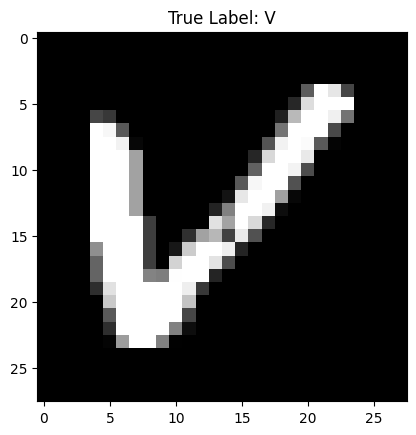

Predicted Alphabet: V


In [39]:
import matplotlib.pyplot as plt

# Choose an index from the validation set to display
index_to_display = random.randint(0, len(X_val) - 1)

# Display the image
sample_image = X_val[index_to_display].reshape(28, 28)
plt.imshow(sample_image, cmap='gray')
plt.title(f"True Label: {chr(ord('A') + Y_val[index_to_display])}")  # Use the true label
plt.show()

# Use the classify function to get the model's output
image_to_classify = X_val[index_to_display]
predictions = classify(image_to_classify, W1, b1, W2, b2, W3, b3)

# Determine the most likely predicted digit
predicted_digit = np.argmax(predictions)
print(f"Predicted Alphabet: {chr(ord('A') + predicted_digit)}")


In [35]:
# Export weights and biases as numpy files
np.save('W1.npy', W1)
np.save('b1.npy', b1)
np.save('W2.npy', W2)
np.save('b2.npy', b2)
np.save('W3.npy', W3)
np.save('b3.npy', b3)

In [37]:
import zipfile
import os

# List of files to be included in the zip file
files_to_zip = ['W1.npy', 'b1.npy', 'W2.npy', 'b2.npy', 'W3.npy', 'b3.npy']

# Name of the zip file
zip_file_name = 'weights_and_biases_for_alphabets.zip'

# Creating a zip file
with zipfile.ZipFile(zip_file_name, 'w') as zip_file:
    for file in files_to_zip:
        zip_file.write(file)

# Optional: Move the zip file to a specific directory
destination_directory = '/content'
os.rename(zip_file_name, os.path.join(destination_directory, zip_file_name))
